In [ ]:
print("Hello world")

Hello world


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%pip install matplotlib pandas scipy

In [ ]:
%pip install opencv-python

In [ ]:
%pip install tqdm

In [ ]:
%pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.8 MB/s eta 0:00:00


In [ ]:
%pip install --upgrade pip

In [ ]:
%mkdir -p data/Image_data/

In [ ]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

In [ ]:
%pip install split-folders

### Algorithm to convert executables to images

In [ ]:
import math
import numpy as np

def executable_to_rgb(file_path):
    """
    Converts an executable file into an RGB image representation
    based on Algorithm 5.1.
    """
    C = 3 # Number of channels (RGB)

    # Read the executable file as raw bytes
    with open(file_path, 'rb') as f:
        file_bytes = f.read()

    # S <- FileSize(F)
    S = len(file_bytes)

    # R <- ceiling(sqrt(S)) // Image height/width
    R = math.ceil(math.sqrt(S))

    # N <- R * R
    N = R * R

    # Pad_Size <- N - S // Number of padding bytes
    Pad_Size = N - S

    # Create 1D array A and read file bytes into A.
    # In Python, reading 'rb' directly gives us 8-bit values [0, 255].
    # We use np.frombuffer for efficient conversion to a 1D array.
    A = np.frombuffer(file_bytes, dtype=np.uint8)

    # Pad A with Pad_Size bytes of zeros to reach length N if needed
    if Pad_Size > 0:
        A = np.pad(A, (0, Pad_Size), mode='constant', constant_values=0)

    # Create 3D array RGB_Img of size R x R x C
    RGB_Img = np.zeros((R, R, C), dtype=np.uint8)

    # Copy the bytes in A into the 0-th channel of RGB_Img.
    # Note: The algorithm shows explicit nested for-loops (i and j).
    # In Python, we use numpy's `.reshape()` to do this instantly without slow loops.
    RGB_Img[:, :, 0] = A.reshape((R, R))

    # The algorithm mentions converting 8-bit groups to decimal integers [0, 255].
    # Our numpy array using `dtype=np.uint8` handles this inherently!

    # Replicate the values across all C channels to generate RGB_Img
    RGB_Img[:, :, 1] = RGB_Img[:, :, 0]
    RGB_Img[:, :, 2] = RGB_Img[:, :, 0]

    return RGB_Img

In [ ]:
import cv2

In [ ]:
rgbimg = executable_to_rgb('./data/ELF_data/Hello_ELF')

cv2.imshow('RGB Image', rgbimg)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Converting the entire dataset to images

In [ ]:
from pathlib import Path
from tqdm.notebook import tqdm  # Use tqdm.notebook for a cleaner bar in Jupyter

def convert_dataset_to_images(input_dir, output_dir):
    """
    Crawls the input directory, converts files, and saves them to the output directory
    while maintaining the Benignware/Malware folder structure.
    """
    input_path = Path(input_dir)
    output_path = Path(output_dir)

    # We expect these two folders based on your structure
    categories = ['Benignware', 'Malware']

    for category in categories:
        cat_input_dir = input_path / category
        cat_output_dir = output_path / category

        # Create the destination folder (e.g., data/Image_data/ELF_Dataset/Malware)
        cat_output_dir.mkdir(parents=True, exist_ok=True)

        # Grab all files in the current category
        if not cat_input_dir.exists():
            print(f"Warning: Directory {cat_input_dir} not found. Skipping.")
            continue

        files = [f for f in cat_input_dir.iterdir() if f.is_file()]
        print(f"Starting conversion for {category} ({len(files)} files)...")

        # Wrap the file list in tqdm for the progress bar
        for file_path in tqdm(files, desc=f"Processing {category}"):
            try:
                # 1. Generate the image array
                img_array = executable_to_rgb(file_path)

                # 2. Define the new file name (keep original name, change extension to .png)
                save_name = file_path.stem + ".png"
                save_path = cat_output_dir / save_name

                # 3. Save the image to the new directory
                cv2.imwrite(str(save_path), img_array)

            except Exception as e:
                # If an individual file fails (e.g., permission denied, 0 bytes),
                # print the error and continue to the next file.
                print(f"Skipped {file_path.name} due to error: {e}")

# === Setup your paths ===
# Based on your root structure, we read from ELF_data and create a new Image_data folder
INPUT_DIRECTORY = "data/ELF_data/ELF_Dataset"
OUTPUT_DIRECTORY = "data/Image_data/ELF_Dataset"

# Run the process
convert_dataset_to_images(INPUT_DIRECTORY, OUTPUT_DIRECTORY)
print("Dataset conversion complete!")

In [ ]:
%pip install split-folders

Link to data: /content/drive/MyDrive/Data/Image_data

### Splitting folders according to label

In [ ]:
import splitfolders

input_dir = "/content/drive/MyDrive/Data/Image_data"
output_dir = "/content/data/Split_Dataset"

# This will split your data into 80% training, 10% validation, and 10% testing.
# The seed=42 ensures that if you run this again, it makes the exact same random splits.
splitfolders.ratio(input_dir, output=output_dir, seed=42, ratio=(0.9, 0.1))

print("Data successfully split into Train and Test folders!")


Copying files: 966 files [01:05, 14.65 files/s]

Data successfully split into Train and Test folders!


### Using Imagefolder to load images according to folder (label)

In [ ]:
import torch
import torchvision

from torchvision import transforms
from torchvision.datasets import ImageFolder

# train and test data dir
data_dir = '/content/data/Split_Dataset/train/'
test_data_dir = '/content/data/Split_Dataset/test/'

dataset = ImageFolder(data_dir, transform = transforms.Compose([
  transforms.Resize((150, 150)), transforms.ToTensor()
]))

test_dataset = ImageFolder(test_data_dir, transform = transforms.Compose([
  transforms.Resize((150, 150)), transforms.ToTensor()
]))

In [ ]:
img, label = dataset[0]

img.shape, label

(torch.Size([3, 150, 150]), 0)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
print("Following classes are there : ", dataset.classes)

Following classes are there :  ['Benignware', 'Malware']


Label: Benignware


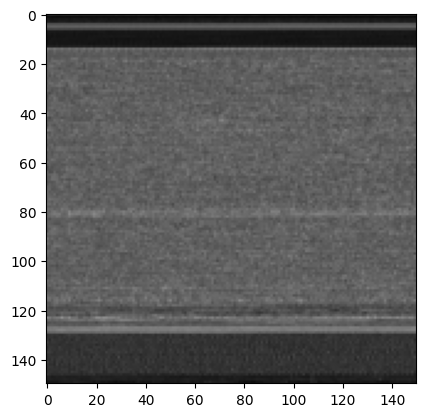

In [ ]:
def display_img(img, label):
  print(f'Label: {dataset.classes[label]}')
  plt.imshow(img.permute(1,2,0))

display_img(*dataset[0])

### Loading data into the notebook

In [ ]:
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split

batch_size = 128
val_size = 200
train_size = len(dataset) - val_size

train_data, val_data = random_split(dataset, [train_size, val_size])
print(f'Length of train data: {len(train_data)}')
print(f'Length of val data: {len(val_data)}')

train_dl = DataLoader(train_data, batch_size, shuffle = True, num_workers = 4, pin_memory = True)
val_dl = DataLoader(val_data, batch_size * 2, num_workers = 4, pin_memory = True)

Length of train data: 669
Length of val data: 200


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


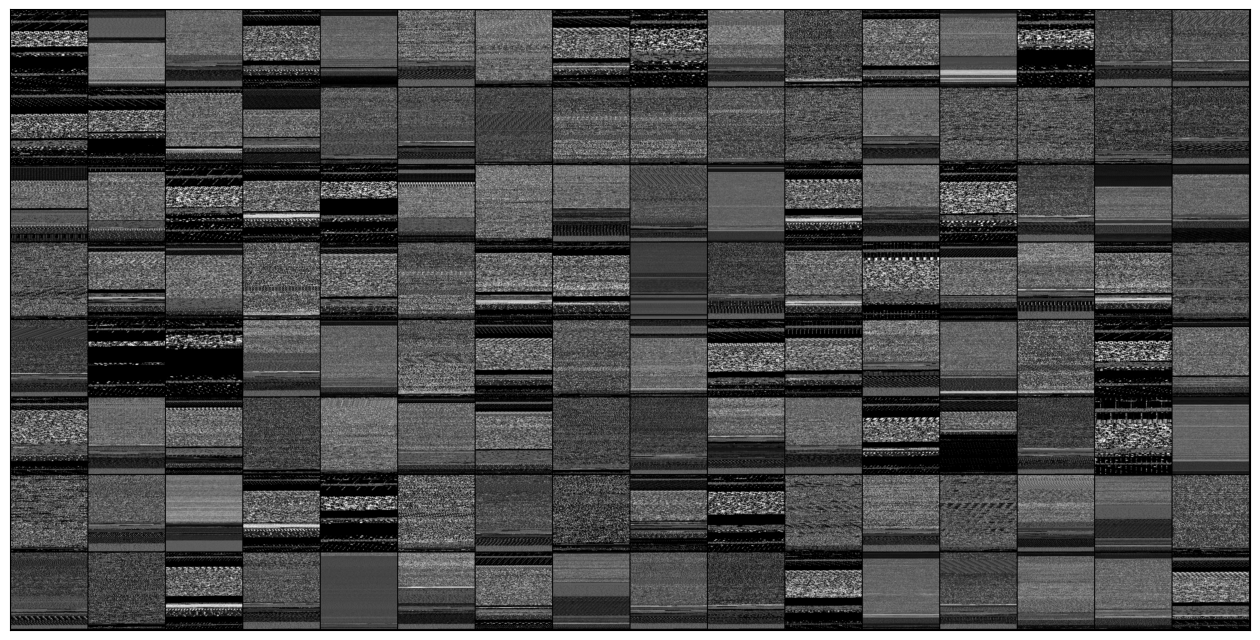

In [ ]:
from torchvision.utils import make_grid

def show_batch(dl):
  for imgs, labels in dl:
    fig, ax = plt.subplots(figsize = (16, 12))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(make_grid(imgs, nrow = 16).permute(1, 2, 0))
    break

show_batch(train_dl)

In [ ]:
%pip install scikit-learn

### Accuracy metric required by next cell

In [ ]:
def accuracy(outputs, labels):
  _, preds = torch.max(outputs, dim = 1)
  return torch.tensor(torch.sum(preds == labels).item() / len(preds))


### Code for base image classifier

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class ImageClassificationBase(nn.Module):

  def training_step(self, batch):
    images, labels = batch
    out = self(images)
    loss = F.cross_entropy(out, labels)
    return loss

  def validataion_step(self, batch):
    images, labels = batch
    out = self(images)
    loss = F.cross_entropy(out, labels)
    acc = accuracy(out, labels)

    return {
        'val_loss' : loss.detach(),
        'val_acc' : acc
    }

  def validation_epoch_end(self, outputs):
    batch_losses = [x['val_loss'] for x in outputs]
    epoch_loss = torch.stack(batch_losses).mean()

    batch_accs = [x['val_acc'] for x in outputs]
    epoch_acc = torch.stack(batch_accs).mean()

    return {
        'val_loss' : epoch_loss.item(),
        'val_acc' : epoch_acc.item()
    }

  def epoch_end(self, epoch, result):
    print("Epoch [{}], train loss : {:.4f}, val_loss : {:.4f}, val_acc : {:.4f}".format(epoch + 1, result['train_loss'], result['val_loss'],
    result['val_acc']))


### Executable image classifier

In [ ]:
class ExecutableClassification(ImageClassificationBase):
  def __init__(self) -> None:
     super().__init__()
     self.network = nn.Sequential(
          nn.Conv2d(3, 32, kernel_size = 3, padding = 1),
          nn.ReLU(),
          nn.Conv2d(32, 64,kernel_size = 3, padding = 1, stride = 1),
          nn.ReLU(),
          nn.MaxPool2d(2,2),

          nn.Conv2d(64, 128, kernel_size = 3, padding = 1, stride = 1),
          nn.ReLU(),
          nn.Conv2d(128, 128, kernel_size = 3, padding = 1, stride = 1),
          nn.ReLU(),
          nn.MaxPool2d(2, 2),

          nn.Conv2d(128, 256, kernel_size = 3, padding = 1, stride = 1),
          nn.ReLU(),
          nn.Conv2d(256, 256, kernel_size = 3, padding = 1, stride = 1),
          nn.ReLU(),
          nn.MaxPool2d(2, 2),

          nn.Flatten(),
          nn.Linear(82944, 1024),
          nn.ReLU(),
          nn.Linear(1024, 512),
          nn.ReLU(),
          nn.Linear(512, 6),
     )

  def forward(self, xb):
    return self.network(xb)

### Other metrics and methods required for training

In [ ]:
@torch.no_grad()
def evaluate(model, val_loader):
  model.eval()
  outputs = [model.validataion_step(batch) for batch in val_loader]
  return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func = torch.optim.SGD):
  history = []
  optimizer = opt_func(model.parameters(), lr)

  for epoch in range(epochs):
    model.train()
    train_losses = []

    for batch in train_loader:
      loss = model.training_step(batch)
      train_losses.append(loss)
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    result = evaluate(model, val_loader)
    result['train_loss'] = torch.stack(train_losses).mean().item()

    model.epoch_end(epoch, result)
    history.append(result)

  return history

In [ ]:
model = ExecutableClassification()
model

ExecutableClassification(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Flatten(start_dim=1, end_dim=-1)
    (16): Linear(in_features=82944, out_features=1024, bias=True)
    (17): ReLU()
    (18): Line

### Using GPU for training purpose

In [ ]:
def get_default_device():
  if torch.cuda.is_available():
    return torch.device('cuda')
  return torch.device('cpu')


def to_device(data, device):
  if isinstance(data, (list, tuple)):
    return [to_device(x, device) for x in data]

  return data.to(device, non_blocking = True)

class DeviceDataLoader():
  def __init__(self, dl, device) -> None:
     self.dl = dl
     self.device = device

  def __iter__(self):
    for b in self.dl:
      yield to_device(b, self.device)

  def __len__(self):
    return len(self.dl)

In [ ]:
device = get_default_device()
device

device(type='cuda')

### Loading data and model into device (GPU)

In [ ]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)

to_device(model, device)

ExecutableClassification(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Flatten(start_dim=1, end_dim=-1)
    (16): Linear(in_features=82944, out_features=1024, bias=True)
    (17): ReLU()
    (18): Line

In [ ]:
model = to_device(ExecutableClassification(), device)

In [ ]:
evaluate(model, val_dl)

{'val_loss': 1.805832028388977, 'val_acc': 0.0}

In [ ]:
num_epochs = 30
opt_func = torch.optim.Adam
lr = 0.001

### The training process

In [ ]:
history = fit(num_epochs, lr, model, train_dl, val_dl, opt_func)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [0], train loss : 4.9142, val_loss : 1.0992, val_acc : 0.4750

Epoch [1], train loss : 1.1312, val_loss : 0.9664, val_acc : 0.4750

Epoch [2], train loss : 0.8186, val_loss : 0.7545, val_acc : 0.5250

Epoch [3], train loss : 0.7180, val_loss : 0.7391, val_acc : 0.4750

Epoch [4], train loss : 0.7131, val_loss : 0.6980, val_acc : 0.5250

Epoch [5], train loss : 0.6985, val_loss : 0.7042, val_acc : 0.4750

Epoch [6], train loss : 0.6977, val_loss : 0.6882, val_acc : 0.5250

Epoch [7], train loss : 0.6908, val_loss : 0.6800, val_acc : 0.8700

Epoch [8], train loss : 0.6802, val_loss : 0.6328, val_acc : 0.7300

Epoch [9], train loss : 0.5629, val_loss : 0.3164, val_acc : 0.9550

Epoch [10], train loss : 0.2120, val_loss : 0.1828, val_acc : 0.9450

Epoch [11], train loss : 0.2662, val_loss : 0.1549, val_acc : 0.9650

Epoch [12], train loss : 0.1930, val_loss : 0.0787, val_acc : 0.9800

Epoch [13], train loss : 0.1163, val_loss : 0.1061, val_acc : 0.9700

Epoch [14], train loss : 0.132

### Plot of accuracies

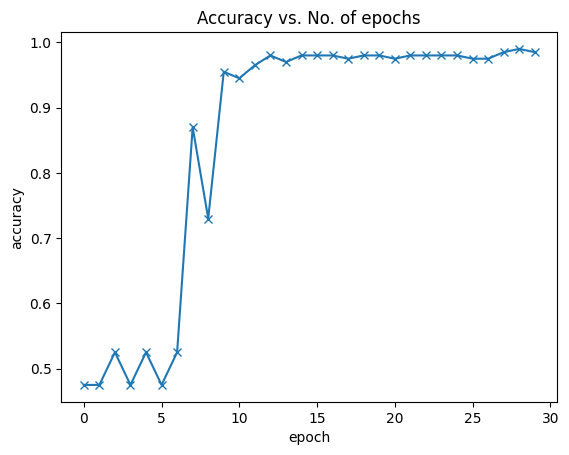

In [ ]:
def plot_accuracies(history):
    """ Plot the history of accuracies"""
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs');


plot_accuracies(history)

### Plot of loss

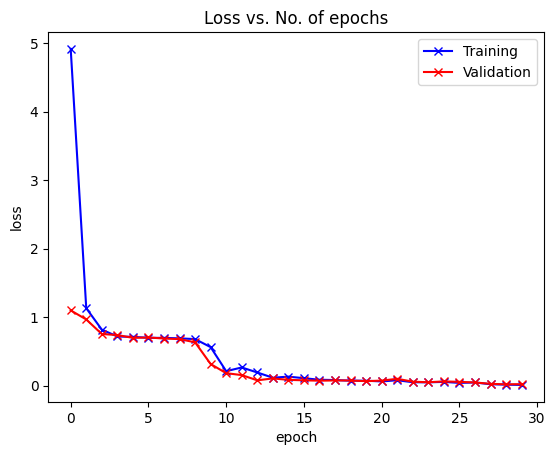

In [ ]:
def plot_losses(history):
    """ Plot the losses in each epoch"""
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs');

plot_losses(history)

In [ ]:
test_dl = DeviceDataLoader(DataLoader(test_dataset, batch_size * 2), device)
result = evaluate(model, test_dl)
result

{'val_loss': 0.14086772501468658, 'val_acc': 0.9793814420700073}